# Índice

## Exploración y Limpieza
1. [Carga del dataset](#s1)
2. [Estructura y valores nulos](#s2)
3. [Limpieza y transformación de datos](#s3)
4. [Correlación entre variables](#s4)

## Análisis Exploratorio
5. [Hipótesis 1 — Descuentos y rentabilidad](#s5)
6. [Hipótesis 2 — Subcategorías y logística](#s6)
7. [Hipótesis 3 — Mercados con pérdidas](#s7)
8. [Hipótesis 4 — Segmentos de cliente y RFM](#s8)

## Machine Learning
9. [Modelo 1 — Predicción de Rentabilidad](#s9)
10. [Modelo 2 — Detección de Churn](#s10)

## Conclusiones
11. [Conclusiones](#s11)

## Introducción

 "La empresa Global Superstore tiene presencia mundial y un alto volumen de ventas, pero necesita identificar focos de ineficiencia financiera (fugas de dinero) y oportunidades de expansión estratégica para maximizar su beneficio neto."

In [2]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy._core.fromnumeric import mean

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, roc_curve, auc,
                             roc_auc_score, precision_recall_curve,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

import xgboost as xgb
import time
import joblib

<a id="s1"></a>

## 1. Carga del dataset

In [6]:
#Inicialmente cargamos el dataset mediante pandas

url = "https://raw.githubusercontent.com/NicoLencina95/Proyecto-Data-Science-II/main/Global_Superstore2.csv"
df = pd.read_csv(url, encoding="latin-1")
df.shape



(51290, 24)

<a id="s2"></a>

## 2. Estructura y valores nulos

In [3]:
#Una vez cargado el dataset, revisamos su estructura, tipos de datos y valores nulos
df.shape

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [4]:
#chequeamos suma de nulos por columna
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [5]:
#Revisamos las primeras filas para entender la estructura de los datos
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


<a id="s3"></a>

## 3. Limpieza y transformación de datos

In [6]:
#Eliminación de columnas innecesarias por valores nulos (Postal Code no aporta información relevante ya que contamos con Región, Estado y Ciudad)
df.drop(columns=['Postal Code'], inplace=True)

In [7]:
#Revisamos tipos de datos por columna para detectar posibles inconsistencias
df.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object

In [8]:
#Cambio de tipo de dato para la columna 'Order Date' y 'Ship Date' a tipo fecha
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

In [9]:
#Agregamos una nueva columna de Unit Price para analizar el precio unitario de cada producto
df['Unit_Price'] = df['Sales'] / df['Quantity']
#Tambien desglozamos las fechas para obtener año y mes de cada orden, lo que nos permitirá analizar tendencias temporales en las ventas
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month


In [10]:
#Clasificamos las columnas en numéricas , categóricas y fechas para facilitar su análisis posterior
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
date_cols = df.select_dtypes(include=['datetime64']).columns
print("Columnas numéricas:", numerical_cols)
print("Columnas categóricas:", categorical_cols)
print("Columnas de fecha:", date_cols)

Columnas numéricas: Index(['Row ID', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost',
       'Unit_Price'],
      dtype='str')
Columnas categóricas: Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'City', 'State', 'Country', 'Market', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Order Priority'],
      dtype='str')
Columnas de fecha: Index(['Order Date', 'Ship Date'], dtype='str')


C:\Users\usuario\AppData\Local\Temp\ipykernel_15704\59158012.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [11]:
#Chequear valores imposibles o inconsistentes

def dq_score(df):
    impossible_values = {
        'Quantity': df[df['Quantity'] < 0].shape[0],
        'Sales': df[df['Sales'] < 0].shape[0],
        'Unit_Price': df[df['Unit_Price'] < 0].shape[0],
        'Discount': df[df['Discount'] < 0].shape[0],
        'Profit': df[df['Profit'] < 0].shape[0]}  
    total_impossible = sum(impossible_values.values())
    total_rows = df.shape[0]
    dq_score = 100 - (total_impossible / total_rows * 100)
    return dq_score, impossible_values  
dq_score_value, impossible_values = dq_score(df)
print(f"DQ Score: {dq_score_value:.2f}%")
print("Valores imposibles encontrados:")
for column, count in impossible_values.items():
    print(f"{column}: {count}")

DQ Score: 75.54%
Valores imposibles encontrados:
Quantity: 0
Sales: 0
Unit_Price: 0
Discount: 0
Profit: 12544


Como vemos, tenemos valores de profit negativos pero eso es común en el mercado ya que a veces es necesario seguir dentro de ciertos mercados
aunque conlleve pérdidas. Estar dentro de esos mercados le aporta a la empresa valores o consideraciones más importantes que el dinero.
Los demás valores estan bien

<a id="s4"></a>

## 4. Correlación entre variables

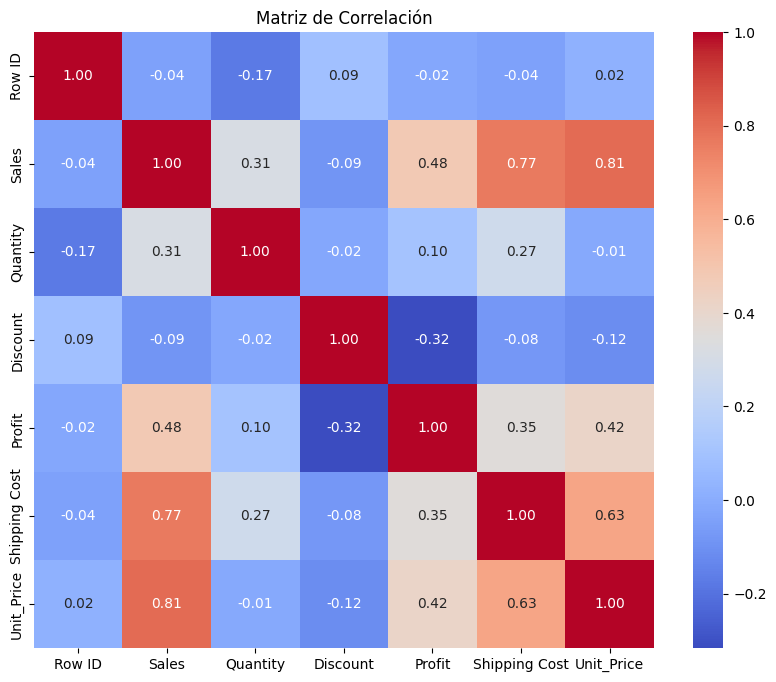

In [12]:
#De acá en adelante comenzamos a analizar los datos para responder a preguntas específicas sobre el negocio, como por ejemplo:
#Correlación entre variables numéricas
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

Considerando las relaciones entre los campos podemos empezar a obtener información valiosa sobre el mercado a nivel mundial.

<a id="s5"></a>

## 5. Hipótesis 1 — Descuentos y rentabilidad

Hipótesis: La política de descuentos agresivos está disminuyendo el margen de ganancia en ciertas regiones sin generar un aumento proporcional en el volumen de ventas.
Preguntas a responder:

        ¿Cuál es la correlación entre el campo de “Discount” y el “Profit”?

        ¿Existe un punto de quiebre donde la venta siempre resulta en pérdida?

        ¿Qué categorías de productos sufren más por los descuentos excesivos?


C:\Users\usuario\AppData\Local\Temp\ipykernel_15704\3793386561.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()]) #Esta linea convierte los valores de X en %


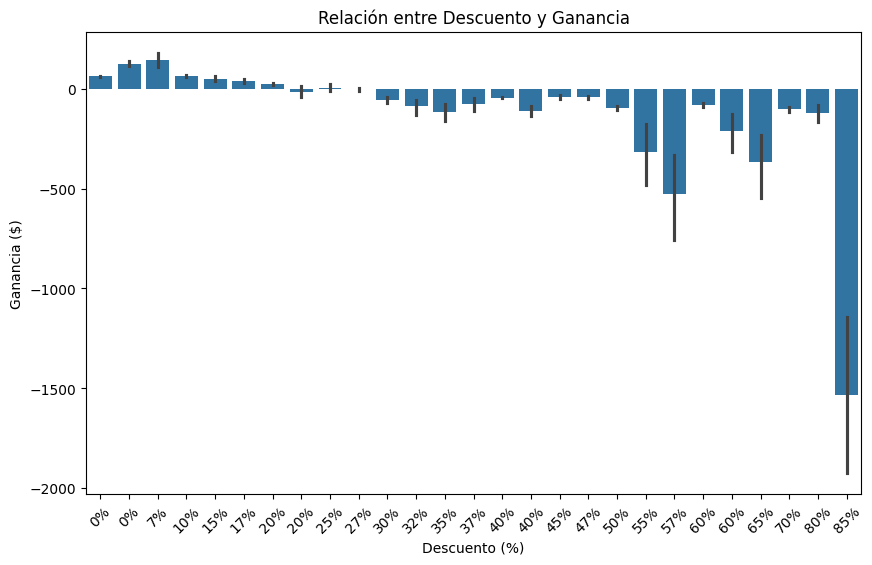

In [13]:
#Correlación entre Discount y Profit por gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Discount', y='Profit', data=df)
plt.title('Relación entre Descuento y Ganancia')
plt.xlabel('Descuento (%)')
plt.ylabel('Ganancia ($)')
plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()]) #Esta linea convierte los valores de X en %
plt.xticks(rotation=45)
plt.show()



Como podemos observar existe una correlación negativa entre el beneficio de las ventas (Profit) y los descuentos ofrecidos (Discount) aunque dentro del rango 0 a 20% se mantiene positiva. Es necesario desglozar entre productos para tener un  valor más acertado de qué descuentos generan mayores beneficios
A partir de este gráfico podemos notar claramente que descuentos mayores a 20% generan pérdida en el mercado por lo que no es aconsejable superar este valor

C:\Users\usuario\AppData\Local\Temp\ipykernel_15704\3906098522.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()])
C:\Users\usuario\AppData\Local\Temp\ipykernel_15704\3906098522.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()])
C:\Users\usuario\AppData\Local\Temp\ipykernel_15704\3906098522.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()])


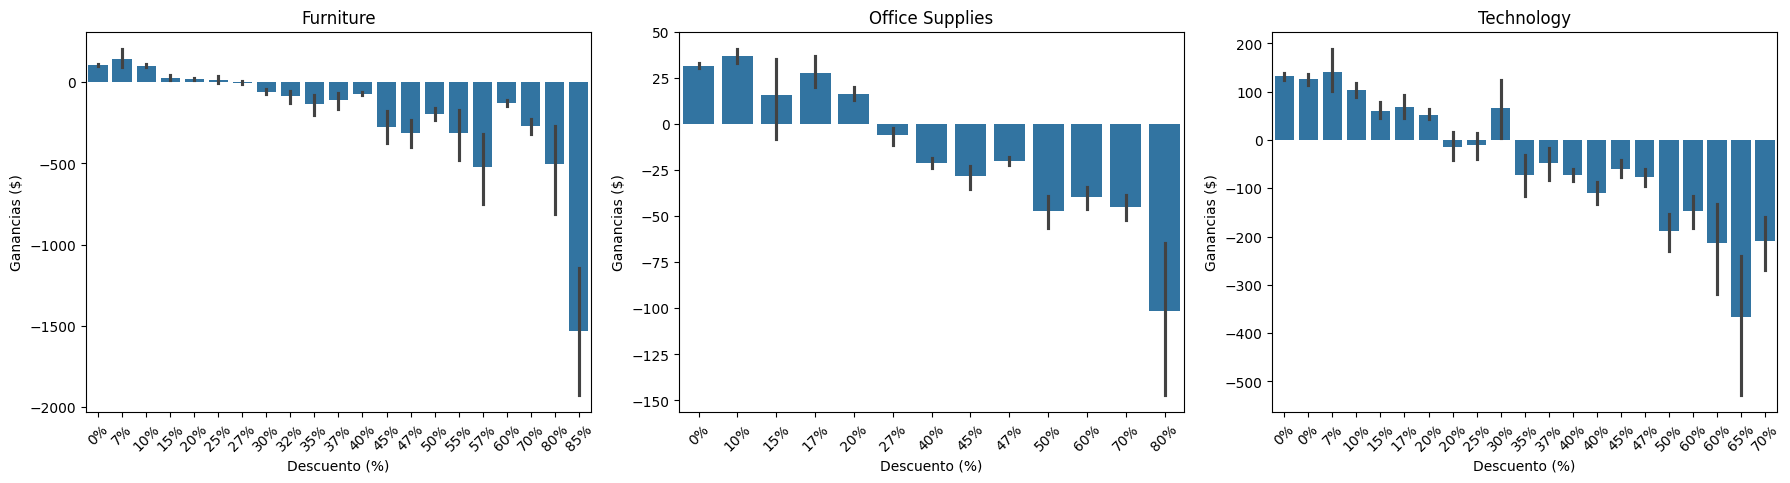

In [14]:
#Categorias que se ven más afectadas por los descuentos en términos de Ganancias ($)
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.barplot(x='Discount', y='Profit', data=df[df['Category'] == 'Furniture'])
plt.title('Furniture')
plt.xlabel('Descuento (%)')
plt.ylabel('Ganancias ($)')
plt.xticks(rotation=45) 
plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()])
plt.subplot(1, 3, 2)
sns.barplot(x='Discount', y='Profit', data=df[df['Category'] == 'Office Supplies'])
plt.title('Office Supplies')
plt.xlabel('Descuento (%)')
plt.ylabel('Ganancias ($)')
plt.xticks(rotation=45)
plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()])
plt.subplot(1, 3, 3)
sns.barplot(x='Discount', y='Profit', data=df[df['Category'] == 'Technology'])
plt.title('Technology')
plt.xlabel('Descuento (%)')
plt.ylabel('Ganancias ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.gca().set_xticklabels([f'{float(t.get_text()):.0%}' for t in plt.gca().get_xticklabels()])
plt.show()



Como podemos observar, la categoría Furniture (Muebles) es la más afectada por los descuentos. Habría que analizar si el costo de shipping es demasiado costoso para cubrir el beneficio de la compra.

En conclusión a estas 3 preguntas:
-La relación de Beneficio y Descuentos es negativa aunque si se ajusta el rango hasta 20% de descuento es productiva obteniendose beneficios y atracción sobre el mercado, siendo el mayor beneficio cercano al 10% de descuento.
-Descuentos mayores al 20% generan pérdidas en el mercado.
-La categoría de productos más afectada por los descuentos es la de Furniture (Muebles)


<a id="s6"></a>

## 6. Hipótesis 2 — Subcategorías y logística

    Hipótesis: Ciertas subcategorías de productos (probablemente las más pesadas o voluminosas) son logísticamente ineficientes y generan pérdidas sistemáticas.
    Preguntas:
    ¿Existen subcategorías que generan pérdidas? ¿Tiene relación respecto a los costos de envío?
    ¿Qué categoría tiene mejor ganancia?
    ¿Cuáles son las 3 subcategorías más rentables y las 3 menos rentables (o con pérdidas)?
    
    


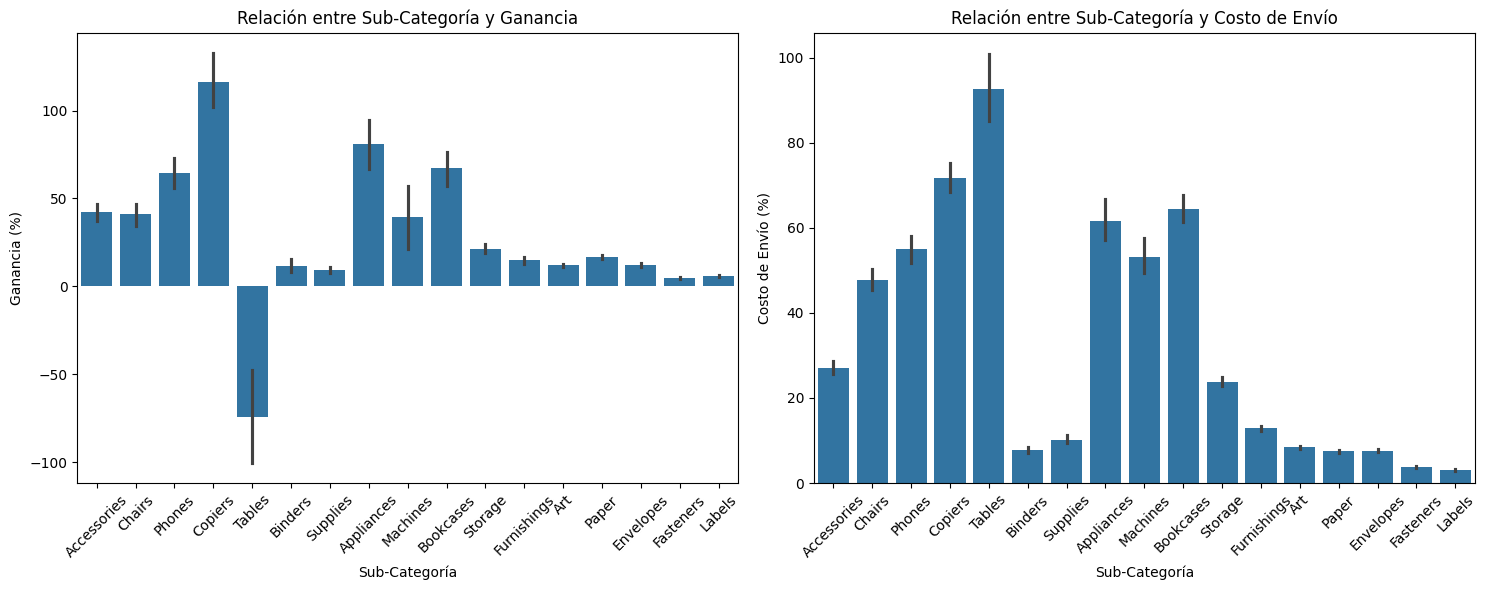

In [15]:
#Correlación entre sub categorias y profit por gráfico de barras
#Correlacion entre Shipping Costo y Subcategoria por gráfico de barras
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Sub-Category', y='Profit', data=df)
plt.title('Relación entre Sub-Categoría y Ganancia')
plt.xlabel('Sub-Categoría')
plt.ylabel('Ganancia (%)')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.barplot(x='Sub-Category', y='Shipping Cost', data=df)
plt.title('Relación entre Sub-Categoría y Costo de Envío')
plt.xlabel('Sub-Categoría')
plt.ylabel('Costo de Envío (%)')
plt.xticks(rotation=45)
plt.tight_layout()


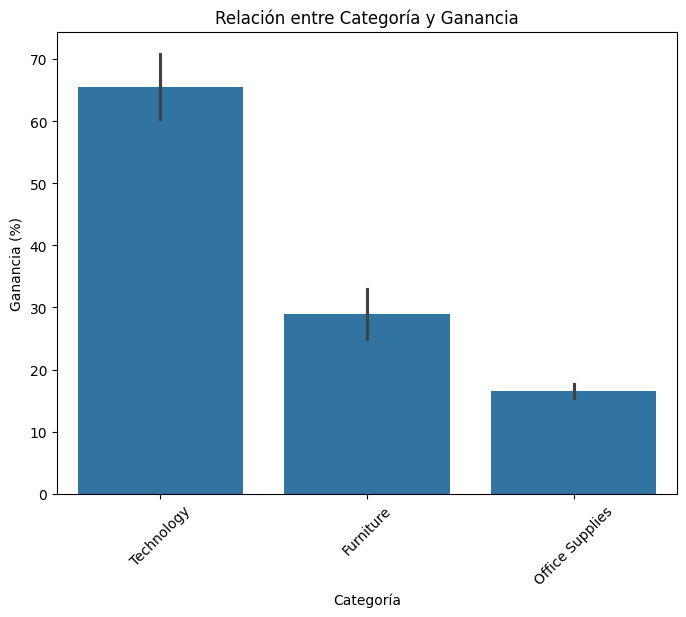

In [16]:
#Correlacion entre Category y Profit por gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x='Category', y='Profit', data=df)
plt.title('Relación entre Categoría y Ganancia')
plt.xlabel('Categoría')
plt.ylabel('Ganancia (%)')
plt.xticks(rotation=45)
plt.show()


-Observando el gráfico, podemos ver que efectivamente una de las Sub-Categorías de productos más pesados termina generando pérdidas en lugar de beneficios y al observar los costos de envío claramente es una Sub-Categoría muy costosa logisticamente. Además es parte de la categoría con descuentos más altos por lo que puede ser otro factor que genere demasiadas pérdidas

-La categoría con más ganancias es la de Technology
-Respecto a la siguiente pregunta, los sujetadores, etiquetas y carpetas (Fasteners, Labels y Binders respectivamente) son los productos que generan menor beneficio en cuanto a ventas. Por el otro lado, las Estanterías, Accesorios y Copiadoras (Bookcases, Appliances y Copiers respectivamente) son las más productivas en cuanto a beneficio, siendo la última la mejor por casi el doble de beneficio frente a las demás.


<a id="s7"></a>

## 7. Hipótesis 3 — Mercados con pérdidas

Hipótesis: Existen mercados específicos donde los costos operativos (o de envío) superan los ingresos, haciendo que la presencia en esos países sea insostenible.

    Preguntas a responder:

        ¿Qué países tienen Ventas (Sales) altas, pero Ganancia (Profit) negativa?

        ¿Cómo varían los costos de envío (Shipping Cost) por región? ¿Son desproporcionados en algún continente?   

        ¿Qué mercado es el más rentable en términos absolutos y cuál en términos relativos (margen)?

        


In [17]:
#Agrupamos por País para sumar métricas
analisis_pais = df.groupby('Country')[['Sales', 'Profit', 'Shipping Cost']].sum()

#Filtramos para quedarnos solo con los que tienen Ganancia NEGATIVA
paises_con_perdidas = analisis_pais[analisis_pais['Profit'] < 0]

#Ordenamos de mayor a menor las ventas
#Así vemos primero los países donde facturamos millones pero perdemos dinero.
top_problemas = paises_con_perdidas.sort_values('Sales', ascending=False)

#Resultados
print("--- Países con 'Fugas de Dinero' (Ventas Altas / Profit Negativo) ---")
print(top_problemas.head(10)) # Mostramos los 10 casos más graves

--- Países con 'Fugas de Dinero' (Ventas Altas / Profit Negativo) ---
                           Sales       Profit  Shipping Cost
Country                                                     
Philippines         183420.16500 -16128.22500       17882.51
Dominican Republic  126140.58128  -7613.49872       14588.39
Turkey              108507.94800 -98447.23200       11664.16
Honduras             90125.64860 -29482.37140        9671.80
Netherlands          77514.94500 -41070.07500        9005.75
Thailand             77051.95500  -7308.19500        7736.53
Vietnam              65800.19940  -1870.23060        7684.37
Pakistan             58872.61200 -22446.64800        5833.09
Argentina            57511.78328 -18693.79672        6366.51
Nigeria              54350.35200 -80750.71800        6183.11


Como podemos observar en la tabla, se ordenan de mayor a menor los países según su ganancia en ventas manteniendo una ganancia final negativa. Es crucial analizar estos países para disminuir pérdidas


In [18]:
#Agrupamos por mercado y sumamos Ventas y Ganancias
rentabilidad_mercado = df.groupby('Market')[['Sales', 'Profit']].sum()

#Calculamos el Margen Relativo (Profit / Sales) y multiplicamos por 100 para tener el porcentaje
rentabilidad_mercado['Margin_Percent'] = (rentabilidad_mercado['Profit'] / rentabilidad_mercado['Sales']) * 100

#Ordenamos para encontrar los ganadores
# Más rentable en términos absolutos (Dinero total)
top_absoluto = rentabilidad_mercado.sort_values('Profit', ascending=False).head(1)

# Más rentable en términos relativos (Eficiencia/Margen)
top_relativo = rentabilidad_mercado.sort_values('Margin_Percent', ascending=False).head(1)


print("--- Rentabilidad por Mercado ---\n")
print(rentabilidad_mercado.sort_values('Profit', ascending=False))
print(f"\nGanador Absoluto (Más dinero generado): {top_absoluto.index[0]} con ${top_absoluto['Profit'].values[0]:.2f}")
print(f"Ganador Relativo (Mejor margen): {top_relativo.index[0]} con {top_relativo['Margin_Percent'].values[0]:.2f}%")  



--- Rentabilidad por Mercado ---

               Sales        Profit  Margin_Percent
Market                                            
APAC    3.585744e+06  436000.04900       12.159263
EU      2.938089e+06  372829.74150       12.689532
US      2.297201e+06  286397.02170       12.467217
LATAM   2.164605e+06  221643.48708       10.239442
Africa  7.837732e+05   88871.63100       11.338947
EMEA    8.061613e+05   43897.97100        5.445309
Canada  6.692817e+04   17817.39000       26.621660

Ganador Absoluto (Más dinero generado): APAC con $436000.05
Ganador Relativo (Mejor margen): Canada con 26.62%


Considerando este resultado, es importante prestar servicio y atención a estos mercados para que sigan rindiendo eficientemente



Definimos una nueva columna para conocer el promedio de costo de envio por venta, lo que nos permitirá identificar si el costo de envío es un factor importante en las pérdidas de ciertos países



In [19]:
#Costo de Envío Promedio por Venta por País
df['Shipping_Cost_Per_Sale'] = df['Shipping Cost'] / df['Sales']
#Calculamos el costo de envío promedio por venta para las diferentes regiones
costo_envio_por_region = df.groupby('Country')['Shipping Cost'].mean().sort_values(ascending=False)
print("\nCosto de Envío Promedio por Venta por País:")
print(costo_envio_por_region.head(20))




Costo de Envío Promedio por Venta por País:
Country
Taiwan                      155.660714
Chad                        148.970000
Lesotho                     135.650000
Montenegro                   93.937500
Slovenia                     61.220000
Republic of the Congo        59.303333
Central African Republic     57.625714
Namibia                      50.370000
Bangladesh                   46.402883
Estonia                      46.070000
Uruguay                      45.229583
Mauritania                   44.115000
Albania                      43.660625
Qatar                        43.078125
China                        41.998415
Afghanistan                  41.822364
Malaysia                     41.111193
South Sudan                  40.855000
Cambodia                     40.483111
India                        39.730367
Name: Shipping Cost, dtype: float64


In [20]:
#Definimos una función para el análisis 
def analizar_costos_envio(df, columna_agrupacion):
    # Agrupamos y calculamos métricas clave
    analisis = df.groupby(columna_agrupacion).agg({
        'Sales': 'sum',
        'Shipping Cost': 'sum',
        'Profit': 'sum'
    }).reset_index()
    
    #Calculamos el "Ratio de Envío" (% de la venta que se va en envío)
    analisis['Shipping_Ratio_Percent'] = (analisis['Shipping Cost'] / analisis['Sales']) * 100
    
    #Ordenamos por el ratio más alto (los más caros proporcionalmente)
    return analisis.sort_values('Shipping_Ratio_Percent', ascending=False)





#Análisis por Región
print("--- Top 10 Paises con Envíos más Desproporcionados ---")
df_Country = analizar_costos_envio(df, 'Country')
print(df_Country[['Country', 'Shipping_Ratio_Percent', 'Sales']].head(10).round(2))

--- Top 10 Paises con Envíos más Desproporcionados ---
                      Country  Shipping_Ratio_Percent    Sales
126                    Taiwan                   28.50  7647.63
24                       Chad                   22.62  1317.03
122                 Swaziland                   18.43   288.03
1                     Albania                   17.97  3888.12
23   Central African Republic                   16.97  2377.56
72                    Liberia                   16.71  3560.88
99                   Paraguay                   16.67  2590.37
70                    Lebanon                   16.13  2796.66
88                    Namibia                   15.63  2899.47
8                  Azerbaijan                   15.22  5631.51


Podemos observar en la tabla que muchos países poseen valores de costo de envío demasiado altos considerando que por encima del 15% de la compra supone un costo excesivo para obtener ganancias. Por ende, es necesario evaluar estos países para mejorar logística


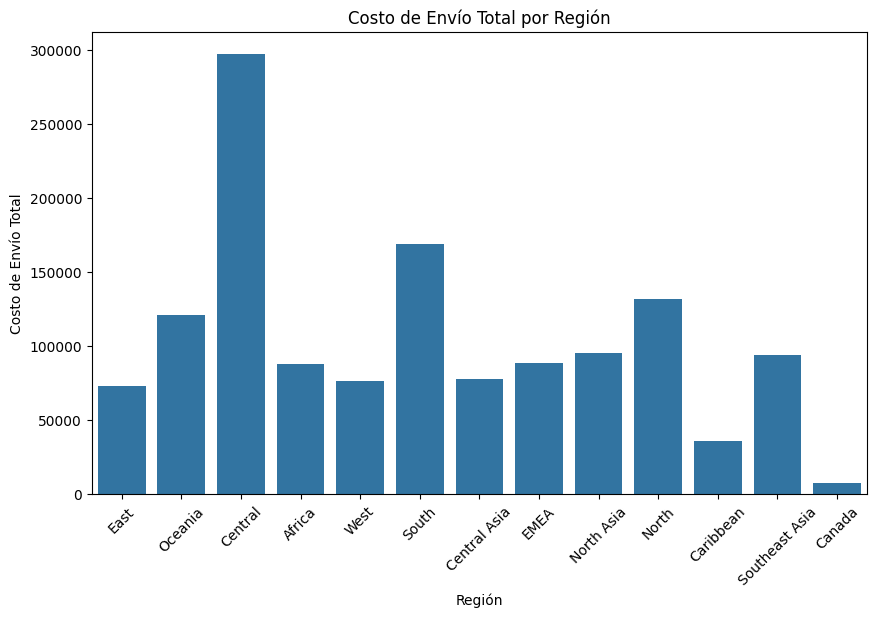

In [21]:
#Grafico de como varian los shipping cost por region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Shipping Cost', data=df, estimator=sum, errorbar=None)
plt.title('Costo de Envío Total por Región')
plt.xlabel('Región')
plt.ylabel('Costo de Envío Total')
plt.xticks(rotation=45)
plt.show()

In [22]:
#Paises dentro de la region Central 
paises_central = df[df['Region'] == 'Central']['Country'].unique()
print("Países en la región Central:")
print(paises_central)


Países en la región Central:
<StringArray>
[      'Germany',        'France', 'United States',   'El Salvador',
     'Nicaragua',       'Austria',   'Netherlands',     'Guatemala',
       'Belgium',   'Switzerland',      'Honduras',        'Panama']
Length: 12, dtype: str


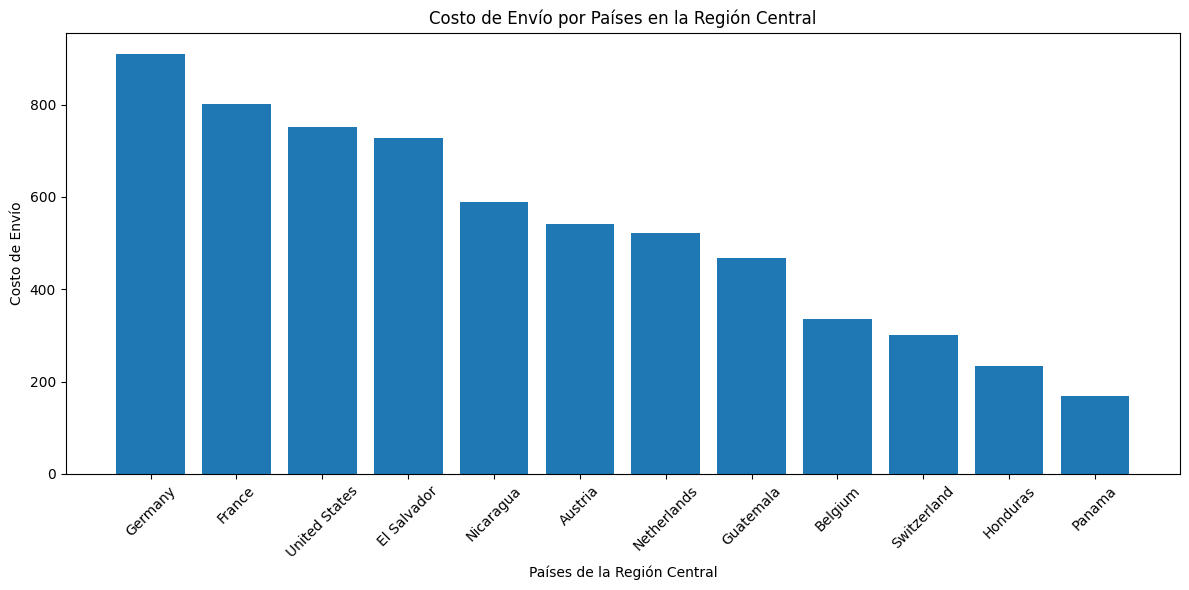

In [23]:
#Grafico de Shipping Cost por paises de la region Central
plt.figure(figsize=(12, 6))
df_central = df[df['Region'] == 'Central']
plt.bar(df_central['Country'], df_central['Shipping Cost'])
plt.xlabel('Países de la Región Central')
plt.ylabel('Costo de Envío')
plt.title('Costo de Envío por Países en la Región Central')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<a id="s8"></a>

## 8. Hipótesis 4 — Segmentos de cliente y RFM

    Hipótesis: El segmento corporativo es más estable y rentable, mientras que el consumidor final es más sensible al precio y requiere más descuentos.

    Preguntas a responder:

        ¿Qué segmento de cliente aporta mayor ganancia promedio por orden?

        ¿Cómo es la frecuencia de compra y el valor monetario (RFM simplificado) entre los diferentes segmentos?

        ¿Y el RFM entre las diferentes regiones?

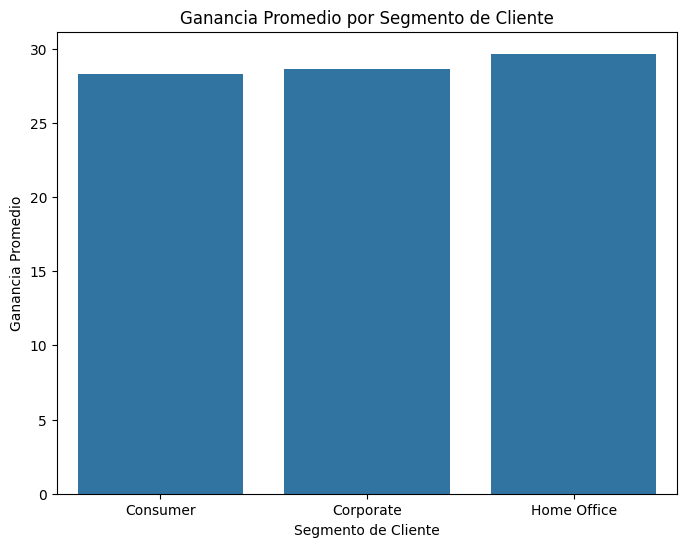

In [24]:
#Qué segmento de cliente aporta mayor ganancia promedio 
plt.figure(figsize=(8, 6))
sns.barplot(x='Segment', y='Profit', data=df, estimator='mean', errorbar=None)
plt.title('Ganancia Promedio por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Ganancia Promedio')
plt.show()


Como podemos observar, la ganancia promedio entre los distintos sectores es similar. Procedemos a analizar sus RFM para detectar diferencias.


In [25]:
# Definimos una función para calcular RFM
def calcular_rfm_segmento(df, col_cliente, col_fecha, col_orden, col_monto, col_segmento):
    
    # Fecha de referencia: El día siguiente a la última venta registrada
    fecha_maxima = df[col_fecha].max() + pd.Timedelta(days=1)
    
    # Agrupamos por Cliente para calcular sus métricas individuales
    rfm_clientes = df.groupby(col_cliente).agg({
        col_fecha: lambda x: (fecha_maxima - x.max()).days, # Recencia: Días desde la última compra
        col_orden: 'nunique',                               # Frecuencia: Cantidad de compras únicas
        col_monto: 'sum',                                   # Valor Monetario: Total gastado
        col_segmento: 'first'                               # Segmento al que pertenece
    }).reset_index()
    
    # Renombramos para que sea legible
    rfm_clientes.columns = ['Cliente_ID', 'Recencia_Dias', 'Frecuencia', 'Valor_Total', 'Segmento']
    
    return rfm_clientes


# Usamos 'Region' como segmento, ya que es lo que tenemos disponible
df_rfm = calcular_rfm_segmento(
    df,                # Tu dataframe limpio
    col_cliente='Customer ID',  # ID del cliente
    col_fecha='Order Date',  # Fecha de la compra
    col_orden='Order ID',    # ID de la orden (para contar cuántas veces vino)
    col_monto='Sales',     # Dinero gastado
    col_segmento='Segment'       # Variable de agrupación
)

# Resumen por Segmento (Promedios)
rfm_resumen = df_rfm.groupby('Segmento')[['Recencia_Dias', 'Frecuencia', 'Valor_Total']].mean().round(2)

print("--- Análisis RFM por Región (Promedios por Cliente) ---")
print(rfm_resumen.sort_values('Valor_Total', ascending=False))

--- Análisis RFM por Región (Promedios por Cliente) ---
             Recencia_Dias  Frecuencia  Valor_Total
Segmento                                           
Corporate            84.22       16.24      8035.08
Consumer             82.83       16.27      7955.93
Home Office          94.58       15.94      7803.56


Al analizar las RFM por segmento notamos leves diferencias a favor de las corporaciones en cuestión de valor total pero no son sustanciales para marcar diferencia


In [26]:
# Definimos una función para calcular RFM por region
def calcular_rfm_region(df, col_cliente, col_fecha, col_orden, col_monto, col_segmento):
    
    # Fecha de referencia: El día siguiente a la última venta registrada
    fecha_maxima = df[col_fecha].max() + pd.Timedelta(days=1)
    
    # Agrupamos por Cliente para calcular sus métricas individuales
    rfm_clientes = df.groupby(col_cliente).agg({
        col_fecha: lambda x: (fecha_maxima - x.max()).days, # Recencia: Días desde la última compra
        col_orden: 'nunique',                               # Frecuencia: Cantidad de compras únicas
        col_monto: 'sum',                                   # Valor Monetario: Total gastado
        col_segmento: 'first'                               # Region al que pertenece
    }).reset_index()
    
    # Renombramos para que sea legible
    rfm_clientes.columns = ['Cliente_ID', 'Recencia_Dias', 'Frecuencia', 'Valor_Total', 'Segmento']
    
    return rfm_clientes


# Usamos 'Region' como segmento, ya que es lo que tenemos disponible
df_rfm = calcular_rfm_region(
    df,                # Tu dataframe limpio
    col_cliente='Customer ID',  # ID del cliente
    col_fecha='Order Date',  # Fecha de la compra
    col_orden='Order ID',    # ID de la orden (para contar cuántas veces vino)
    col_monto='Sales',     # Dinero gastado
    col_segmento='Region'       # Variable de agrupación
)

# Resumen por Segmento (Promedios)
rfm_resumen = df_rfm.groupby('Segmento')[['Recencia_Dias', 'Frecuencia', 'Valor_Total']].mean().round(2)

print("--- Análisis RFM por Región (Promedios por Cliente) ---")
print(rfm_resumen.sort_values('Valor_Total', ascending=False))

--- Análisis RFM por Región (Promedios por Cliente) ---
                Recencia_Dias  Frecuencia  Valor_Total
Segmento                                              
East                    27.11       26.80     14503.81
Central Asia            28.56       25.35     14493.20
North Asia              31.33       26.23     14165.82
West                    26.10       26.25     13959.23
Central                 33.15       25.90     13793.37
Caribbean               22.15       25.80     13786.36
South                   30.74       27.07     13727.41
Southeast Asia          29.34       25.21     13700.30
North                   26.51       26.41     13369.98
Oceania                 28.18       25.17     13229.41
Africa                 139.66        6.24      2139.57
EMEA                   143.93        6.48      2049.52
Canada                 133.26        5.97      1920.19


En este caso, si analizamos las RFM por región podemos detectar que África, EMEA y Canadá tienen las RFM más bajas, destacando sobre todo a Canadá que, a pesar de esto, vimos anteriormente que es el mercado con mejor margen relativo. Considerando estos datos, se debe mejorar la frecuencia de compra haciendo hincapié en este último 


In [27]:
#Calculo para identificar el top 10 de clientes más valiosos (mayor Sales) y su segmento
top_clientes = df_rfm.sort_values('Valor_Total', ascending=False).head(10)
print("\n--- Top 10 Clientes Más Valiosos ---")
print(top_clientes[['Cliente_ID', 'Valor_Total', 'Segmento']])



--- Top 10 Clientes Más Valiosos ---
     Cliente_ID  Valor_Total   Segmento
1463   TA-21385  35668.12080       East
623    GT-14710  34471.89028      North
1489   TC-20980  34218.26900    Central
1405   SM-20320  31125.29496  Caribbean
237    BW-11110  30613.61650    Central
656    HL-15040  29664.23058    Oceania
1369   SE-20110  29532.62502    Central
1220   PS-19045  29252.31940      South
1243   RB-19360  29197.63460    Oceania
1587   ZC-21910  28472.81926    Central


Dentro del TOP 10 de Clientes, hay 4 que se encuentran en la region central, zona que tiene los mayores costos de shipping. Si queremos mantener esos clientes sería adecuado favorecerlos con costos de envío promocionales a fines de incentivar sus compras.

<a id="s9"></a>

## 9. Modelo 1 — Predicción de Rentabilidad

¿Podemos predecir si una transacción generará pérdidas antes de que se concrete? En retail, dar un descuento inadecuado o enviar un producto pesado a una zona lejana puede destruir el margen. Entrenaremos un algoritmo para predecir si una orden será Rentable (1) o No Rentable (0) basándonos en sus características.

Antes de que el modelo pueda aprender, necesitamos traducir el negocio a un idioma que la máquina entienda (números) y crear variables que aporten valor predictivo.

-Creación del Target: Crearemos una columna binaria Es_Rentable (1 si el Profit es mayor a 0, 0 si hay pérdida).

-Manejo de Fechas: Extraeremos el mes y el trimestre de la Order Date para capturar la estacionalidad.

-Codificación de Variables Categóricas: Transformaremos texto como Category o Market en números usando One-Hot Encoding.

-Escalado: Normalizaremos variables numéricas como Sales y Shipping Cost para que el algoritmo no le dé más peso a una solo porque tiene números más grandes.

In [28]:
#Transformación de datos para Machine Learning (Ingeniería de Características)

# Creamos una copia de trabajo para estar 100% seguros de no alterar el df original
df_ml = df.copy()

# ---------------------------------------------------------
# 1. CREACIÓN DEL TARGET (Variable a predecir)
# ---------------------------------------------------------
# Objetivo: Predecir si la transacción generará ganancias.
# Regla: Si Profit > 0, asignamos 1 (Rentable). Si Profit <= 0, asignamos 0 (Pérdida).
df_ml['Target_Es_Rentable'] = np.where(df_ml['Profit'] > 0, 1, 0)

# ---------------------------------------------------------
# 2. INGENIERÍA DE FECHAS (Temporalidad)
# ---------------------------------------------------------
# Convertimos la fecha original a un formato temporal en una NUEVA columna
df_ml['Feat_Order_Date_DT'] = pd.to_datetime(df_ml['Order Date'], errors='coerce')

# Extraemos el Mes (1 al 12) y el Trimestre (1 al 4) para capturar la estacionalidad
df_ml['Feat_Mes'] = df_ml['Feat_Order_Date_DT'].dt.month
df_ml['Feat_Trimestre'] = df_ml['Feat_Order_Date_DT'].dt.quarter

# ---------------------------------------------------------
# 3. INGENIERÍA DE VARIABLES DE NEGOCIO (Ratios)
# ---------------------------------------------------------
# Calculamos el costo de envío como porcentaje de la venta.
# Usamos np.where para evitar errores si alguna venta fuera exactamente 0.
df_ml['Feat_Shipping_Ratio'] = np.where(df_ml['Sales'] > 0, 
                                        df_ml['Shipping Cost'] / df_ml['Sales'], 
                                        0)

# ---------------------------------------------------------
# 4. VERIFICACIÓN
# ---------------------------------------------------------
columnas_revision = [
    'Order Date', 'Feat_Mes', 'Feat_Trimestre', 
    'Profit', 'Target_Es_Rentable', 
    'Shipping Cost', 'Sales', 'Feat_Shipping_Ratio'
]

print("--- Muestra de la Ingeniería de Características ---")
print("Observar si las columnas originales siguen intactas junto a las nuevas:\n")
display(df_ml[columnas_revision].head(5))

--- Muestra de la Ingeniería de Características ---
Observar si las columnas originales siguen intactas junto a las nuevas:



,Order Date,Feat_Mes,Feat_Trimestre,Profit,Target_Es_Rentable,Shipping Cost,Sales,Feat_Shipping_Ratio
0,2012-07-31,7,3,762.1845,1,933.57,2309.650,0.404204
1,2013-02-05,2,1,-288.7650,0,923.63,3709.395,0.248997
2,2013-10-17,10,4,919.9710,1,915.49,5175.171,0.176900
3,2013-01-28,1,1,-96.5400,0,910.16,2892.510,0.314661
4,2013-11-05,11,4,311.5200,1,903.04,2832.960,0.318762


Etapa 1 de Machine Learning

-Creamos un modelo sencillo para tener un punto de comparación.

Algoritmo: Árbol de Decisión simple.

Objetivo: Obtener una métrica base. Si este modelo simple acierta el 70% de las veces, nuestro objetivo en los siguientes pasos será superar ese 70% optimizando parámetros.

In [29]:
#Entrenamos modelo sencillo para definir rentabilidad de ventas

print("Preparando el modelo base...")

# ---------------------------------------------------------
# 1. DEFINIR VARIABLES (Evitando la "Fuga de Datos")
# ---------------------------------------------------------
# IMPORTANTE: No podemos incluir 'Profit' en las variables predictoras (X), 
# porque el Target se creó a partir de ella.

variables_categoricas = ['Category', 'Sub-Category', 'Market', 'Ship Mode', 'Segment']
variables_numericas = ['Sales', 'Quantity', 'Discount', 'Shipping Cost', 'Feat_Mes', 'Feat_Shipping_Ratio']

X = df_ml[variables_categoricas + variables_numericas]
y = df_ml['Target_Es_Rentable']

# ---------------------------------------------------------
# 2. DIVIDIR LOS DATOS (Train / Test)
# ---------------------------------------------------------
# Guardamos el 80% para que el modelo estudie, y el 20% para tomarle un examen.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. CREAR EL PIPELINE (El túnel de procesamiento)
# ---------------------------------------------------------
# Le decimos a Python cómo tratar cada tipo de dato:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas), # Escala los números para que estén proporcionados
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas) # Convierte texto a 1s y 0s
    ])

# Armamos el pipeline con un Árbol de Decisión simple (max_depth=4 para que no sea muy complejo)
modelo_base = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('algoritmo', DecisionTreeClassifier(max_depth=4, random_state=42))
])

# ---------------------------------------------------------
# 4. ENTRENAR Y EVALUAR
# ---------------------------------------------------------
print("Entrenando...")
modelo_base.fit(X_train, y_train)

# Tomamos el examen con los datos de prueba
predicciones_base = modelo_base.predict(X_test)

# Calculamos la precisión
exactitud = accuracy_score(y_test, predicciones_base)
#Calculamos AUC-ROC para evaluar la capacidad de distinguir entre pérdidas y ganancias
from sklearn.metrics import roc_auc_score
roc_auc_base = roc_auc_score(y_test, predicciones_base)

 




print("\n--- RESULTADOS DEL MODELO BASE ---")
print(f"Exactitud (Accuracy): {exactitud:.2%}")
print("\nReporte Detallado:")
print(classification_report(y_test, predicciones_base, target_names=['Pérdida (0)', 'Rentable (1)']))
print(f"ROC-AUC Score: {roc_auc_base:.4f}")


Preparando el modelo base...
Entrenando...

--- RESULTADOS DEL MODELO BASE ---
Exactitud (Accuracy): 91.59%

Reporte Detallado:
              precision    recall  f1-score   support

 Pérdida (0)       0.90      0.77      0.83      2696
Rentable (1)       0.92      0.97      0.94      7562

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.91      0.92      0.91     10258

ROC-AUC Score: 0.8689


Las métricas obtenidas son muy buenas aunque si observamos el recall de pérdida es 0.77 y eso se podría optimizar ajustando hiperparámetros.

Esto significa que el modelo es muy bueno detectando las ventas rentables, pero se le está escapando el 23% de las operaciones que dan pérdida.

Para ilustrar este modelo, vamos a generar dos gráficos. El primero será la Curva ROC, que es el estándar de la industria para mostrar qué tan bien separa el modelo las dos clases. El segundo será un Gráfico de Dispersión (Scatter), donde veremos visualmente la frontera de decisión del algoritmo utilizando dos de las variables más críticas (Ventas y Descuento).

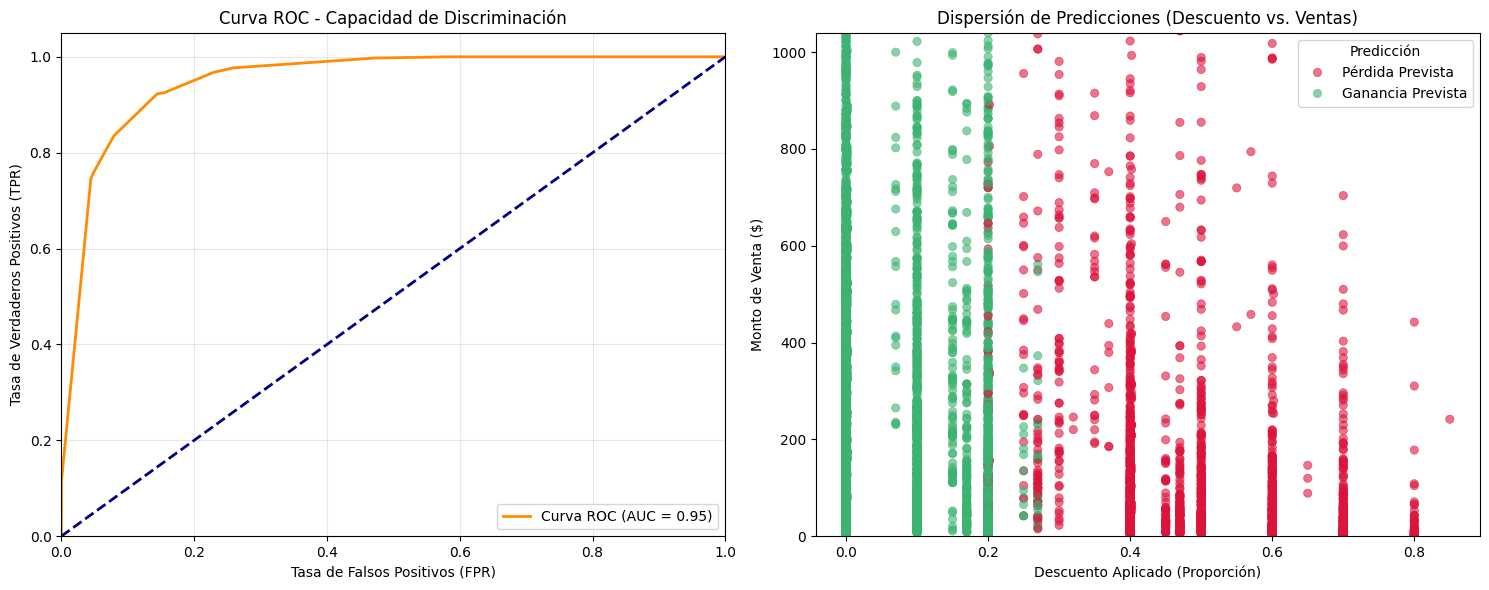

In [30]:
#Representación gráfica de la curva ROC y la frontera de decisión del modelo


# 1. OBTENER PROBABILIDADES
# Para la curva ROC necesitamos la probabilidad (0 a 1), no solo la etiqueta final (0 o 1)
y_prob = modelo_base.predict_proba(X_test)[:, 1]

# Calcular métricas para la curva
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 2. CONFIGURAR LIENZO (1 Fila, 2 Columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- GRÁFICO 1: CURVA ROC ---
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de suerte (50/50)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC - Capacidad de Discriminación')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# --- GRÁFICO 2: DISPERSIÓN (Frontera de Decisión Visual) ---
# Mostramos cómo clasificó el modelo basándose en el Descuento y el Monto de Venta
sns.scatterplot(
    ax=axes[1],
    x=X_test['Discount'], 
    y=X_test['Sales'], 
    hue=predicciones_base, # Coloreamos según lo que PREDIJO el algoritmo
    palette={0: 'crimson', 1: 'mediumseagreen'}, # Rojo para pérdida, Verde para ganancia
    alpha=0.6,
    edgecolor=None
)

# Ajustes visuales del scatter
axes[1].set_title('Dispersión de Predicciones (Descuento vs. Ventas)')
axes[1].set_xlabel('Descuento Aplicado (Proporción)')
axes[1].set_ylabel('Monto de Venta ($)')

# Limitamos el eje Y al percentil 95 para que los valores extremos no aplasten la visualización
limite_y = X_test['Sales'].quantile(0.95)
axes[1].set_ylim(0, limite_y)

# Cambiar la leyenda para que sea legible
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=['Pérdida Prevista', 'Ganancia Prevista'], title='Predicción')

plt.tight_layout()
plt.show()

En el gráfico de dispersión, solo estamos viendo el problema a través de una "ventana" de dos dimensiones: Descuento y Ventas. Sin embargo, tu Árbol de Decisión se entrenó usando muchas más variables (Categoría, Costo de Envío, Región, Mes, etc.).

Imagina dos ventas que en el gráfico caen exactamente en el mismo punto (ejemplo: $500 de Venta con 20% de Descuento). En ese gráfico 2D están superpuestas. Pero para el algoritmo son distintas:

--Punto 1 (Verde): Son $500 en la categoría "Tecnología", enviada localmente (Costo de envío bajo). El modelo la clasifica como Rentable.

--Punto 2 (Rojo): Son $500 en "Muebles" (que son pesados), enviada a otro continente (Costo de envío altísimo). El modelo la clasifica como Pérdida.

Al aplastar todas esas dimensiones complejas en un gráfico plano de 2D, vemos esa "mezcla" en la frontera. El modelo está tomando decisiones basándose en reglas ocultas en las otras variables que no estamos graficando.

Un solo Árbol de Decisión es como preguntarle a un solo experto; puede sesgarse o memorizar datos. Vamos a usar un Random Forest (Bosque Aleatorio), que crea cientos de árboles distintos y los hace votar.

Además, aplicaremos Validación Cruzada (Grid Search). Esto significa que se probarán automáticamente múltiples combinaciones de "perillas" (hiperparámetros) para encontrar la configuración óptima sin que nosotros tengamos que adivinar.

In [31]:
#Entrenamiento con modelo RandomForest y validación cruzada para optimizar hiperparámetros


print("Iniciando la optimización del modelo (Esto puede tomar unos minutos)...")
inicio = time.time()

# 1. ACTUALIZAR EL PIPELINE CON RANDOM FOREST
# Mantenemos el mismo preprocesador del Paso 2
modelo_avanzado = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('algoritmo', RandomForestClassifier(random_state=42, class_weight='balanced')) 
    # class_weight='balanced' es CLAVE aquí. Le dice al modelo: "Presta más atención 
    # a las pérdidas (clase minoritaria) porque me importa mucho detectarlas".
])

# 2. DEFINIR LA CUADRÍCULA DE PARÁMETROS (La búsqueda del tesoro)
# Python probará todas las combinaciones posibles de esta lista:
parametros_grid = {
    'algoritmo__n_estimators': [50, 100, 150],     # ¿Cuántos árboles plantamos en el bosque?
    'algoritmo__max_depth': [5, 10, 15],           # ¿Qué tan profundo dejamos que crezca cada árbol?
    'algoritmo__min_samples_split': [2, 5]         # ¿Cuántos datos mínimos para tomar una nueva decisión?
}

# 3. CONFIGURAR LA VALIDACIÓN CRUZADA (GridSearchCV)
# cv=3 significa que dividirá los datos en 3 partes, entrenando en 2 y probando en 1, rotando para evitar overfitting.
# scoring='recall_macro' le dice que optimice para encontrar mejor AMBAS clases, no solo la ganancia fácil.
optimizador = GridSearchCV(
    estimator=modelo_avanzado,
    param_grid=parametros_grid,
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1, # Usa todos los núcleos de tu procesador para ir más rápido
    verbose=1
)

# 4. ENTRENAR Y BUSCAR EL MEJOR MODELO
optimizador.fit(X_train, y_train)

tiempo_total = time.time() - inicio

# 5. EVALUAR AL CAMPEÓN
mejor_modelo = optimizador.best_estimator_
predicciones_optimizadas = mejor_modelo.predict(X_test)
exactitud_opt = accuracy_score(y_test, predicciones_optimizadas)

print(f"\n¡Optimización completada en {tiempo_total:.1f} segundos!")
print("\n--- LOS MEJORES PARÁMETROS ENCONTRADOS ---")
print(optimizador.best_params_)

print("\n--- RESULTADOS DEL MODELO OPTIMIZADO (RANDOM FOREST) ---")
print(f"Exactitud Global: {exactitud_opt:.2%}")
print("\nReporte Detallado:")
print(classification_report(y_test, predicciones_optimizadas, target_names=['Pérdida (0)', 'Rentable (1)']))

#Calculamos AUC-ROC para evaluar la capacidad de distinguir entre pérdidas y ganancias
roc_auc_opt = roc_auc_score(y_test, predicciones_optimizadas)




print(f"ROC-AUC Score: {roc_auc_opt:.4f}")

Iniciando la optimización del modelo (Esto puede tomar unos minutos)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

¡Optimización completada en 77.0 segundos!

--- LOS MEJORES PARÁMETROS ENCONTRADOS ---
{'algoritmo__max_depth': 5, 'algoritmo__min_samples_split': 2, 'algoritmo__n_estimators': 150}

--- RESULTADOS DEL MODELO OPTIMIZADO (RANDOM FOREST) ---
Exactitud Global: 91.23%

Reporte Detallado:
              precision    recall  f1-score   support

 Pérdida (0)       0.86      0.80      0.83      2696
Rentable (1)       0.93      0.95      0.94      7562

    accuracy                           0.91     10258
   macro avg       0.89      0.88      0.88     10258
weighted avg       0.91      0.91      0.91     10258

ROC-AUC Score: 0.8764


Podemos observar que las métricas fluctuaron y logramos 0.03 puntos en el recall de pérdida lo cual es clave para el mercado disminuir esas fugas.

Tambien logramos aumentar el valor de ROC-AUC que nos indica que tan bien separa el modelo los datos para tomar desiciones precisas.

Procedemos a extraer el modelo y analizar gráficamente qué variables son las que mas inciden en la toma de estas desiciones

C:\Users\usuario\AppData\Local\Temp\ipykernel_15704\1588679186.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


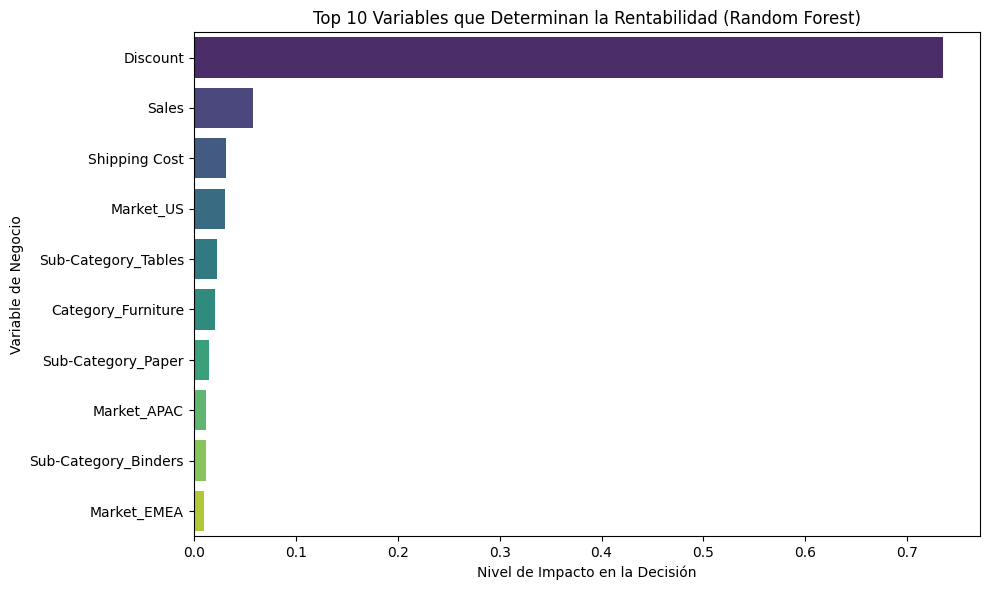

In [32]:
#Extraer el modelo entrenado del pipeline
# El pipeline tiene dos pasos: 'preprocesamiento' y 'algoritmo'. Sacamos el 'algoritmo'.
modelo_rf = mejor_modelo.named_steps['algoritmo']

# 2. Extraer los nombres de las columnas transformadas
# Las numéricas quedan igual
nombres_numericos = variables_numericas 

# Las categóricas se transformaron en muchas columnas (ej: Category_Furniture, Category_Technology)
# Le pedimos al preprocesador que nos dé los nombres exactos que generó
transformador_cat = mejor_modelo.named_steps['preprocesamiento'].named_transformers_['cat']
nombres_categoricos = transformador_cat.get_feature_names_out(variables_categoricas).tolist()

# Unimos todos los nombres en el orden correcto
todos_los_nombres = nombres_numericos + nombres_categoricos

# 3. Obtener la importancia matemática de cada variable
importancia = modelo_rf.feature_importances_

# 4. Crear un DataFrame para ordenar y visualizar fácilmente
df_importancia = pd.DataFrame({
    'Variable': todos_los_nombres,
    'Importancia': importancia
})

# Nos quedamos solo con el Top 10 para que el gráfico sea legible
top_10_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# 5. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=top_10_importancia, 
    palette='viridis'
)

plt.title('Top 10 Variables que Determinan la Rentabilidad (Random Forest)')
plt.xlabel('Nivel de Impacto en la Decisión')
plt.ylabel('Variable de Negocio')
plt.tight_layout()
plt.show()
#Eliminar warning de SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # Desactiva el warning de SettingWithCopyWarning

Claramente el valor de descuento es el factor más importante a considerar para no tener pérdidas en el mercado.

Por útlimo, vamos a correr estos parámetros por medio de XGBoost para analizar el modelo.
Para entender el cambio de paradigma: mientras que Random Forest crea cientos de árboles de forma paralela e independiente, XGBoost (Extreme Gradient Boosting) trabaja de forma secuencial. Planta un árbol, analiza en qué se equivocó, y el siguiente árbol se construye con el único propósito de corregir los errores del anterior.

In [33]:
#Entrenamiento con modelo XGBoost y validación cruzada para optimizar hiperparámetros


print("Iniciando la optimización con XGBoost (Esto puede tomar unos minutos)...")
inicio = time.time()

# 1. ACTUALIZAR EL PIPELINE CON XGBOOST
# Usamos el mismo preprocesador que armamos en los pasos anteriores
modelo_xgb = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('algoritmo', xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss'
    )) 
])

# 2. DEFINIR LA CUADRÍCULA DE PARÁMETROS (Hiperparámetros clave de XGBoost)
# Nota: En XGBoost solemos usar árboles menos profundos que en Random Forest
parametros_xgb = {
    'algoritmo__n_estimators': [100, 200, 300],          # Cantidad de árboles secuenciales
    'algoritmo__max_depth': [3, 5, 7],                   # Profundidad (evitamos > 10 para no hacer overfitting)
    'algoritmo__learning_rate': [0.01, 0.05, 0.1]        # Qué tan rápido o agresivo aprende de los errores pasados
}

# 3. CONFIGURAR LA VALIDACIÓN CRUZADA
optimizador_xgb = GridSearchCV(
    estimator=modelo_xgb,
    param_grid=parametros_xgb,
    cv=3, 
    scoring='f1_macro', # Seguimos optimizando para equilibrar la detección de ambas clases
    n_jobs=-1,
    verbose=1
)

# 4. ENTRENAR Y BUSCAR EL MEJOR MODELO
optimizador_xgb.fit(X_train, y_train)

tiempo_total = time.time() - inicio

# 5. EVALUAR AL CAMPEÓN XGBOOST
mejor_modelo_xgb = optimizador_xgb.best_estimator_
predicciones_xgb = mejor_modelo_xgb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
exactitud_xgb = accuracy_score(y_test, predicciones_xgb)

print(f"\n¡Optimización con XGBoost completada en {tiempo_total:.1f} segundos!")
print("\n--- LOS MEJORES PARÁMETROS ENCONTRADOS ---")
print(optimizador_xgb.best_params_)

print("\n--- RESULTADOS DEL MODELO OPTIMIZADO (XGBOOST) ---")
print(f"Exactitud Global: {exactitud_xgb:.2%}")
print("\nReporte Detallado:")
print(classification_report(y_test, predicciones_xgb, target_names=['Pérdida (0)', 'Rentable (1)']))

#Calculamos AUC-ROC para evaluar la capacidad de distinguir entre pérdidas y ganancias
roc_auc_xgb = roc_auc_score(y_test, predicciones_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")





Iniciando la optimización con XGBoost (Esto puede tomar unos minutos)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

¡Optimización con XGBoost completada en 17.8 segundos!

--- LOS MEJORES PARÁMETROS ENCONTRADOS ---
{'algoritmo__learning_rate': 0.05, 'algoritmo__max_depth': 5, 'algoritmo__n_estimators': 300}

--- RESULTADOS DEL MODELO OPTIMIZADO (XGBOOST) ---
Exactitud Global: 91.59%

Reporte Detallado:
              precision    recall  f1-score   support

 Pérdida (0)       0.90      0.76      0.83      2696
Rentable (1)       0.92      0.97      0.94      7562

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.91     10258

ROC-AUC Score: 0.8668


In [34]:
#Entrenamiento con modelo XGBoost balanceado para mejorar la detección de pérdidas (clase minoritaria)


print("Iniciando la revancha: XGBoost Balanceado...")
inicio = time.time()

# 1. CALCULAR EL PESO PARA EL DESBALANCEO
# Contamos cuántos 0s y 1s hay en los datos de entrenamiento
cantidad_perdidas = (y_train == 0).sum()
cantidad_rentables = (y_train == 1).sum()

# Calculamos el ratio (Minoría / Mayoría)
peso_balanceo = cantidad_perdidas / cantidad_rentables
print(f"Peso aplicado a la clase mayoritaria: {peso_balanceo:.3f}")

# 2. ACTUALIZAR EL MODELO CON EL PESO
modelo_xgb_bal = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('algoritmo', xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        scale_pos_weight=peso_balanceo # <--- ¡Aquí está la magia!
    )) 
])

# 3. MANTENEMOS LOS MEJORES PARÁMETROS QUE YA ENCONTRÓ ANTES
# Para no hacerte esperar, le pasamos directo los ganadores del run anterior
parametros_xgb_bal = {
    'algoritmo__n_estimators': [100, 200, 300],          
    'algoritmo__max_depth': [2,5, 7 ],                   
    'algoritmo__learning_rate': [0.01, 0.05, 0.1]        
}

# 4. ENTRENAR Y EVALUAR
optimizador_xgb_bal = GridSearchCV(
    estimator=modelo_xgb_bal,
    param_grid=parametros_xgb_bal,
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1
)

optimizador_xgb_bal.fit(X_train, y_train)

tiempo_total = time.time() - inicio

mejor_modelo_xgb_bal = optimizador_xgb_bal.best_estimator_
predicciones_xgb_bal = mejor_modelo_xgb_bal.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
exactitud_xgb_bal = accuracy_score(y_test, predicciones_xgb_bal)

print(f"\n¡Entrenamiento completado en {tiempo_total:.1f} segundos!")
print("\n--- RESULTADOS DEL XGBOOST BALANCEADO ---")
print(f"Exactitud Global: {exactitud_xgb_bal:.2%}")
print("\nReporte Detallado:")
print(classification_report(y_test, predicciones_xgb_bal, target_names=['Pérdida (0)', 'Rentable (1)']))


#calculamos el ROC-AUC para ver si realmente mejoró la capacidad de detectar las pérdidas
from sklearn.metrics import roc_auc_score
roc_auc_bal = roc_auc_score(y_test, predicciones_xgb_bal)
print(f"ROC-AUC Score: {roc_auc_bal:.4f}")





Iniciando la revancha: XGBoost Balanceado...
Peso aplicado a la clase mayoritaria: 0.345

¡Entrenamiento completado en 15.2 segundos!

--- RESULTADOS DEL XGBOOST BALANCEADO ---
Exactitud Global: 91.65%

Reporte Detallado:
              precision    recall  f1-score   support

 Pérdida (0)       0.90      0.77      0.83      2696
Rentable (1)       0.92      0.97      0.94      7562

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.91     10258

ROC-AUC Score: 0.8682


In [35]:
#Mejores parámetros encontrados para el modelo XGBoost balanceado
print(optimizador_xgb.best_params_)

{'algoritmo__learning_rate': 0.05, 'algoritmo__max_depth': 5, 'algoritmo__n_estimators': 300}


Observando las métricas, si bien realizó el entrenamiento mucho más rápido (96 seg vs 16 seg) las medidas de presición y recall fueron algo peor al igual que los valores de ROC-AUC. En ese sentido es mejor quedarse con el modelo anterior de RandomForest.

<a id="s10"></a>

## 10. Modelo 2 — Detección de Churn

Ahora pasamos a otro insight para predecir si un cliente es posible que abandone nuestro mercado
Este algoritmo es importante porque nos permitirá contactar a aquellos clientes para retenerlos en el mercado y ofrecer opciones y ofertas que sirvan tanto para el cliente como para nuestro negocio.

In [36]:
#Optimización de datos para predicción de clientes en riesgo de fuga


# Asegurarnos de que Order Date sea formato fecha
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 1. DEFINIR LA MÁQUINA DEL TIEMPO (Fecha de corte)
# Vamos a usar los últimos 6 meses (180 días) como nuestra ventana de predicción.
fecha_maxima = df['Order Date'].max()
fecha_corte = fecha_maxima - pd.Timedelta(days=180)

print(f"Simularemos estar parados en la fecha: {fecha_corte.date()}")
print(f"Intentaremos predecir si el cliente comprará antes del: {fecha_maxima.date()}\n")

# 2. DIVIDIR EL DATASET (Pasado vs. Futuro)
df_pasado = df[df['Order Date'] <= fecha_corte].copy()
df_futuro = df[df['Order Date'] > fecha_corte].copy()

# 3. INGENIERÍA DE CARACTERÍSTICAS (El perfil del cliente en el pasado)
# Agrupamos por Cliente y generamos las columnas 'Feat_'
df_churn = df_pasado.groupby('Customer ID').agg(
    Feat_Dias_Desde_Ultima_Compra=('Order Date', lambda x: (fecha_corte - x.max()).days), # Recencia
    Feat_Frecuencia_Compras=('Order ID', 'nunique'),                                      # Frecuencia
    Feat_Gasto_Total=('Sales', 'sum'),                                                    # Valor Monetario
    Feat_Descuento_Promedio=('Discount', 'mean'),                                         # ¿Solo compra con rebajas?
    Feat_Devoluciones=('Profit', lambda x: (x < 0).sum())                                 # Cantidad de veces que dio pérdida
).reset_index()

# 4. CREACIÓN DEL TARGET (¿Nos abandonó?)
# Obtenemos la lista de los clientes fieles que SÍ compraron en el 'futuro' (los últimos 6 meses)
clientes_fieles = df_futuro['Customer ID'].unique()

# Si un cliente del pasado NO está en la lista de fieles, es un cliente fugado (Churn = 1)
df_churn['Target_Churn'] = np.where(df_churn['Customer ID'].isin(clientes_fieles), 0, 1)

# 5. REVISIÓN
print("--- Dataset para Predicción de Churn Listo ---")
display(df_churn.head())

tasa_fuga = df_churn['Target_Churn'].mean()
print(f"\nTasa de Fuga (Churn Rate): {tasa_fuga:.2%} de los clientes nos abandonaron en ese semestre.")

Simularemos estar parados en la fecha: 2014-07-04
Intentaremos predecir si el cliente comprará antes del: 2014-12-31

--- Dataset para Predicción de Churn Listo ---


,Customer ID,Feat_Dias_Desde_Ultima_Compra,Feat_Frecuencia_Compras,Feat_Gasto_Total,Feat_Descuento_Promedio,Feat_Devoluciones,Target_Churn
0,AA-10315,4,15,10402.60200,0.133333,7,0
1,AA-10375,137,17,4070.13700,0.217241,10,0
2,AA-10480,49,19,17667.77078,0.068432,4,0
3,AA-10645,8,30,13491.03190,0.113567,13,0
4,AA-315,29,5,2212.46400,0.200000,2,0



Tasa de Fuga (Churn Rate): 13.66% de los clientes nos abandonaron en ese semestre.


La tasa de clientes en riesgo es baja, probablemente el entrenamiento del modelo esté desbalanceado y se amolde a detectar más facil el grupo seguro pero vamos a intentarlo. Empezamos por un modelo sencillo con RandomForestClassifier

In [37]:
#Entrenamiento de un modelo RFC para predecir la fuga de clientes (Churn)


# 1. DEFINIR VARIABLES
features_churn = [
    'Feat_Dias_Desde_Ultima_Compra', 
    'Feat_Frecuencia_Compras', 
    'Feat_Gasto_Total', 
    'Feat_Descuento_Promedio', 
    'Feat_Devoluciones'
]

y_churn = df_churn['Target_Churn']

# 2. DIVISIÓN DE DATOS (Conservando el ID del cliente)
# Usamos stratify=y_churn para asegurarnos de que el 13.66% de fuga se mantenga en train y test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df_churn[['Customer ID'] + features_churn], 
    y_churn, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_churn 
)

# Separamos los IDs para no usarlos matemáticamente en el modelo (eso sería un error grave)
test_ids = X_test_c['Customer ID']
X_train_c = X_train_c[features_churn]
X_test_c = X_test_c[features_churn]

# 3. ENTRENAMIENTO DEL MODELO (Random Forest)
print("Entrenando detector de fuga de clientes...")
modelo_churn = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)
modelo_churn.fit(X_train_c, y_train_c)

# 4. EVALUACIÓN GENERAL
predicciones_churn = modelo_churn.predict(X_test_c)
print("\n--- RESULTADOS DEL MODELO DE CHURN ---")
print(classification_report(y_test_c, predicciones_churn, target_names=['Retenido (0)', 'Fuga (1)']))

# 5. EL ENTREGABLE DE NEGOCIO: LA LISTA NEGRA
# Aquí le pedimos al modelo el % exacto de riesgo de abandono para cada cliente
probabilidad_fuga = modelo_churn.predict_proba(X_test_c)[:, 1]

# Armamos la tabla final para el equipo de Marketing
df_riesgo = pd.DataFrame({
    'Customer ID': test_ids,
    'Probabilidad_Fuga': probabilidad_fuga
})

# Unimos con sus datos originales para ver su perfil
df_riesgo_completo = df_riesgo.merge(df_churn, on='Customer ID')
df_top_riesgo = df_riesgo_completo.sort_values(by='Probabilidad_Fuga', ascending=False)

print("\n--- TOP 10 CLIENTES EN ALTO RIESGO DE ABANDONO ---")
print("¡A estos clientes hay que enviarles una promoción urgente!")
display(df_top_riesgo[['Customer ID', 'Probabilidad_Fuga', 'Feat_Dias_Desde_Ultima_Compra', 'Feat_Descuento_Promedio', 'Target_Churn']].head(10).style.format({
    'Probabilidad_Fuga': '{:.1%}', 
    'Feat_Descuento_Promedio': '{:.1%}'
}))
#Calculamos AUC-ROC para evaluar la capacidad de distinguir entre clientes que se van y los que se quedan
from sklearn.metrics import roc_auc_score
roc_auc_churn = roc_auc_score(y_test_c, predicciones_churn)
print(f"ROC-AUC Score del modelo de Churn: {roc_auc_churn:.4f}")

Entrenando detector de fuga de clientes...

--- RESULTADOS DEL MODELO DE CHURN ---
              precision    recall  f1-score   support

Retenido (0)       0.99      0.57      0.73       275
    Fuga (1)       0.26      0.98      0.42        43

    accuracy                           0.63       318
   macro avg       0.63      0.78      0.57       318
weighted avg       0.90      0.63      0.69       318


--- TOP 10 CLIENTES EN ALTO RIESGO DE ABANDONO ---
¡A estos clientes hay que enviarles una promoción urgente!


,Customer ID,Probabilidad_Fuga,Feat_Dias_Desde_Ultima_Compra,Feat_Descuento_Promedio,Target_Churn
49,MY-7380,77.1%,142,35.0%,1
263,GH-4485,76.0%,198,28.0%,0
152,JC-6105,75.0%,136,45.0%,0
202,KM-6225,74.4%,191,43.3%,1
178,CC-2610,74.0%,164,30.0%,1
45,JS-5880,73.8%,28,28.0%,1
4,DP-3165,73.7%,80,40.0%,0
55,LD-6855,73.6%,372,52.5%,0
246,PF-9225,73.1%,303,32.7%,0
74,DM-3345,72.9%,248,44.0%,0


ROC-AUC Score del modelo de Churn: 0.7756


Dado que los datos eran escasos para entrenar el modelo se probaron diversos algoritmos y métricas hasta que encontramos que la ventana temporal utilizada era una métrica importante a considerar ya que al haber pocos casos de riesgo el algoritmo daba valores muy bajos de detección. Debajo dejo comentado el codigo utilizado para encontrar la mejor ventana temporal para el algoritmo.

In [38]:
#Modelo final para predecir la fuga de clientes (Churn) con validación cruzada y optimización de hiperparámetros

# ── 1. DEFINIR VENTANA TEMPORAL ──────────────────────────────────
# Features se calculan sobre historial ANTES de fecha_corte
# Target: ¿compró DESPUÉS de fecha_corte?
df['Order Date'] = pd.to_datetime(df['Order Date'])
fecha_maxima = df['Order Date'].max()
fecha_corte  = fecha_maxima - pd.Timedelta(days=105) #Ventana de predicción de 3.5 meses (105 días) ajustada para tener suficiente muestra de clientes activos

df_hist   = df[df['Order Date'] <  fecha_corte]  # datos históricos
df_futuro = df[df['Order Date'] >= fecha_corte]  # ventana de predicción

clientes_activos = set(df_futuro['Customer ID'].unique())

# ── 2. FUNCIÓN DE TENDENCIA DE GASTO ────────────────────────────
def calcular_tendencia(series_fechas, series_ventas):
    """Pendiente de ventas en el tiempo. Negativa = cliente se aleja."""
    if len(series_fechas) < 2:
        return 0.0
    dias = (series_fechas - series_fechas.min()).dt.days.values
    return np.polyfit(dias, series_ventas.values, 1)[0]  # pendiente lineal

# ── 3. CONSTRUIR FEATURES POR CLIENTE ───────────────────────────
def construir_features_churn(df_hist):
    features = []

    for cliente_id, grupo in df_hist.groupby('Customer ID'):
        grupo = grupo.sort_values('Order Date')
        ordenes = grupo['Order ID'].nunique()
        fechas  = grupo.drop_duplicates('Order ID')['Order Date'].sort_values()

        # Días entre compras
        diffs = fechas.diff().dt.days.dropna()
        dias_entre_compras_promedio = diffs.mean() if len(diffs) > 0 else 999
        variabilidad_entre_compras  = diffs.std()  if len(diffs) > 1 else 0

        # Ratio actividad: meses con compras / meses como cliente
        meses_activo = max((fechas.max() - fechas.min()).days / 30, 1)
        meses_con_compra = grupo.groupby(grupo['Order Date'].dt.to_period('M')).ngroups
        ratio_actividad = meses_con_compra / meses_activo

        features.append({
            'Customer ID': cliente_id,
            'Segmento':    grupo['Segment'].mode()[0],
            'Mercado':     grupo['Market'].mode()[0],

            # Recencia y frecuencia
            'Dias_Desde_Ultima_Compra':     (fecha_corte - fechas.max()).days,
            'Frecuencia':                   ordenes,
            'Dias_Entre_Compras_Promedio':  dias_entre_compras_promedio,
            'Variabilidad_Entre_Compras':   variabilidad_entre_compras,
            'Meses_Activo':                 meses_activo,
            'Ratio_Actividad':              ratio_actividad,

            # Valor y rentabilidad
            'Gasto_Total':                  grupo['Sales'].sum(),
            'Gasto_Promedio_Por_Orden':     grupo['Sales'].mean(),
            'Gasto_Maximo_Orden':           grupo['Sales'].max(),
            'Profit_Promedio':              grupo['Profit'].mean(),
            'Porcentaje_Ordenes_Perdida':   (grupo['Profit'] < 0).mean(),

            # Tendencia de gasto
            'Tendencia_Gasto': calcular_tendencia(
                grupo.drop_duplicates('Order ID').set_index('Order ID')['Order Date'],
                grupo.drop_duplicates('Order ID').set_index('Order ID')['Sales']
            ),

            # Sensibilidad al descuento
            'Descuento_Promedio':           grupo['Discount'].mean(),
            'Descuento_Maximo':             grupo['Discount'].max(),
            'Compra_Solo_Con_Descuento':    (grupo['Discount'] > 0).mean(),

            # Diversidad
            'Num_Categorias_Distintas':     grupo['Category'].nunique(),
            'Num_Subcategorias_Distintas':  grupo['Sub-Category'].nunique(),
            'Num_Productos_Distintos':      grupo['Product Name'].nunique(),

            # Logística
            'Shipping_Promedio':            grupo['Shipping Cost'].mean(),
            'ShipMode_Premium':             grupo['Ship Mode'].isin(['Same Day', 'First Class']).mean(),
        })

    return pd.DataFrame(features)

df_churn = construir_features_churn(df_hist)

# ── 4. TARGET ────────────────────────────────────────────────────
df_churn['Target_Churn'] = (~df_churn['Customer ID'].isin(clientes_activos)).astype(int)

print(f"Clientes totales: {len(df_churn)}")
print(f"Churn rate: {df_churn['Target_Churn'].mean():.1%}")

# ── 5. FEATURES Y TARGET ─────────────────────────────────────────
variables_categoricas = ['Segmento', 'Mercado']
variables_numericas = [
    'Dias_Desde_Ultima_Compra', 'Frecuencia', 'Dias_Entre_Compras_Promedio',
    'Variabilidad_Entre_Compras', 'Meses_Activo', 'Ratio_Actividad',
    'Gasto_Total', 'Gasto_Promedio_Por_Orden', 'Gasto_Maximo_Orden',
    'Profit_Promedio', 'Porcentaje_Ordenes_Perdida', 'Tendencia_Gasto',
    'Descuento_Promedio', 'Descuento_Maximo', 'Compra_Solo_Con_Descuento',
    'Num_Categorias_Distintas', 'Num_Subcategorias_Distintas',
    'Num_Productos_Distintos', 'Shipping_Promedio', 'ShipMode_Premium'
]

X = df_churn[variables_categoricas + variables_numericas].fillna(0)
y = df_churn['Target_Churn']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ── 6. PIPELINE ───────────────────────────────────────────────────
preprocesador = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas),
    ('num', StandardScaler(),                       variables_numericas)
])

pipeline_churn = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# ── 7. BÚSQUEDA DE HIPERPARÁMETROS ───────────────────────────────
param_grid = {
    'modelo__n_estimators':     [100, 200, 300],
    'modelo__max_depth':        [4, 6, 8, None],
    'modelo__min_samples_leaf': [5, 10, 20],
    'modelo__max_features':     ['sqrt', 0.5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

buscador = RandomizedSearchCV(
    pipeline_churn, param_grid,
    n_iter=30, scoring='roc_auc',
    cv=cv, n_jobs=-1, random_state=42, verbose=1
)

buscador.fit(X_train_c, y_train_c)

print(f"\nMejores parámetros: {buscador.best_params_}")
'''
print(f"ROC-AUC en CV:      {buscador.best_score_:.4f}")
'''
print(f"ROC-AUC en test:    {roc_auc_score(y_test_c, buscador.predict_proba(X_test_c)[:,1]):.4f}")

# ── 8. UMBRAL ÓPTIMO ─────────────────────────────────────────────
probabilidades = buscador.predict_proba(X_test_c)[:, 1]
precision_c, recall_c, umbrales_c = precision_recall_curve(y_test_c, probabilidades)

PRECISION_MINIMA = 0.40
mascara = precision_c[:-1] >= PRECISION_MINIMA
recall_filtrado = recall_c[:-1].copy()
recall_filtrado[~mascara] = 0

umbral_optimo = umbrales_c[np.argmax(recall_filtrado)]
print(f"\nUmbral óptimo: {umbral_optimo:.3f}")

# ── 9. REPORTE FINAL ─────────────────────────────────────────────
pred_final = (probabilidades >= umbral_optimo).astype(int)
print(classification_report(y_test_c, pred_final, target_names=['Activo (0)', 'Churn (1)']))


Clientes totales: 1590
Churn rate: 23.4%
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores parámetros: {'modelo__n_estimators': 100, 'modelo__min_samples_leaf': 20, 'modelo__max_features': 0.5, 'modelo__max_depth': 6}
ROC-AUC en test:    0.8229

Umbral óptimo: 0.149
              precision    recall  f1-score   support

  Activo (0)       0.97      0.57      0.72       244
   Churn (1)       0.40      0.95      0.56        74

    accuracy                           0.66       318
   macro avg       0.69      0.76      0.64       318
weighted avg       0.84      0.66      0.68       318



In [39]:
#Detección de mejor ventana temporal para predecir la fuga de clientes (Churn)
'''



def construir_features_churn_ventana(df_hist, fecha_corte):
    features = []
    for cliente_id, grupo in df_hist.groupby('Customer ID'):
        grupo = grupo.sort_values('Order Date')
        ordenes = grupo['Order ID'].nunique()
        fechas  = grupo.drop_duplicates('Order ID')['Order Date'].sort_values()

        diffs = fechas.diff().dt.days.dropna()
        dias_entre_compras_promedio = diffs.mean() if len(diffs) > 0 else 999
        variabilidad_entre_compras  = diffs.std()  if len(diffs) > 1 else 0

        meses_activo     = max((fechas.max() - fechas.min()).days / 30, 1)
        meses_con_compra = grupo.groupby(grupo['Order Date'].dt.to_period('M')).ngroups
        ratio_actividad  = meses_con_compra / meses_activo

        features.append({
            'Customer ID': cliente_id,
            'Segmento':    grupo['Segment'].mode()[0],
            'Mercado':     grupo['Market'].mode()[0],
            'Dias_Desde_Ultima_Compra':     (fecha_corte - fechas.max()).days,
            'Frecuencia':                   ordenes,
            'Dias_Entre_Compras_Promedio':  dias_entre_compras_promedio,
            'Variabilidad_Entre_Compras':   variabilidad_entre_compras,
            'Meses_Activo':                 meses_activo,
            'Ratio_Actividad':              ratio_actividad,
            'Gasto_Total':                  grupo['Sales'].sum(),
            'Gasto_Promedio_Por_Orden':     grupo['Sales'].mean(),
            'Gasto_Maximo_Orden':           grupo['Sales'].max(),
            'Profit_Promedio':              grupo['Profit'].mean(),
            'Porcentaje_Ordenes_Perdida':   (grupo['Profit'] < 0).mean(),
            'Tendencia_Gasto':              calcular_tendencia(
                grupo.drop_duplicates('Order ID').set_index('Order ID')['Order Date'],
                grupo.drop_duplicates('Order ID').set_index('Order ID')['Sales']
            ),
            'Descuento_Promedio':           grupo['Discount'].mean(),
            'Descuento_Maximo':             grupo['Discount'].max(),
            'Compra_Solo_Con_Descuento':    (grupo['Discount'] > 0).mean(),
            'Num_Categorias_Distintas':     grupo['Category'].nunique(),
            'Num_Subcategorias_Distintas':  grupo['Sub-Category'].nunique(),
            'Num_Productos_Distintos':      grupo['Product Name'].nunique(),
            'Shipping_Promedio':            grupo['Shipping Cost'].mean(),
            'ShipMode_Premium':             grupo['Ship Mode'].isin(['Same Day', 'First Class']).mean(),
        })
    return pd.DataFrame(features)


# ── BÚSQUEDA DEL MEJOR VENTANA TEMPORAL ─────────────────────────
resultados = []
ventanas = range(90, 181, 15)  # 90, 105, 120, 135, 150, 165, 180 días

for dias in ventanas:
    fecha_corte_test = fecha_maxima - pd.Timedelta(days=dias)
    
    # Recalcular target con esta ventana
    df_hist_test = df[df['Order Date'] < fecha_corte_test]
    clientes_activos_test = set(df[df['Order Date'] >= fecha_corte_test]['Customer ID'])
    
    df_test = construir_features_churn_ventana(df_hist_test, fecha_corte_test)
    df_test['Target'] = (~df_test['Customer ID'].isin(clientes_activos_test)).astype(int)
    
    churn_rate = df_test['Target'].mean()
    n_churn = df_test['Target'].sum()
    
    # ROC-AUC rápido con modelo simple (sin GridSearch para ser rápido)
    if n_churn >= 20:  # mínimo de casos para evaluar
        X_t = df_test[variables_categoricas + variables_numericas].fillna(0)
        y_t = df_test['Target']
        
        pipe_rapido = Pipeline([
            ('pre', ColumnTransformer([
                ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas),
                ('num', StandardScaler(), variables_numericas)
            ])),
            ('mod', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
        ])
        
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        auc = cross_val_score(pipe_rapido, X_t, y_t, scoring='roc_auc', cv=cv).mean()
    else:
        auc = 0
    
    resultados.append({'Dias': dias, 'Churn_Rate': churn_rate, 'N_Churn': n_churn, 'ROC_AUC': auc})
    print(f"Ventana {dias} días → Churn: {churn_rate:.1%} ({n_churn} clientes) | ROC-AUC: {auc:.4f}")

# ── ELEGIR LA MEJOR VENTANA ──────────────────────────────────────
df_resultados = pd.DataFrame(resultados)
mejor_ventana = df_resultados.loc[df_resultados['ROC_AUC'].idxmax(), 'Dias']
print(f"\nMejor ventana: {int(mejor_ventana)} días")
print(df_resultados.to_string(index=False))

# ── USAR LA MEJOR VENTANA PARA EL ENTRENAMIENTO FINAL ────────────
fecha_corte = fecha_maxima - pd.Timedelta(days=int(mejor_ventana))
df_hist     = df[df['Order Date'] <  fecha_corte]
clientes_activos = set(df[df['Order Date'] >= fecha_corte]['Customer ID'])

df_churn = construir_features_churn(df_hist)
df_churn['Target_Churn'] = (~df_churn['Customer ID'].isin(clientes_activos)).astype(int)
print(f"\nEntrenando con ventana de {int(mejor_ventana)} días → Churn rate: {df_churn['Target_Churn'].mean():.1%}")
'''

'\n\n\n\ndef construir_features_churn_ventana(df_hist, fecha_corte):\n    features = []\n    for cliente_id, grupo in df_hist.groupby(\'Customer ID\'):\n        grupo = grupo.sort_values(\'Order Date\')\n        ordenes = grupo[\'Order ID\'].nunique()\n        fechas  = grupo.drop_duplicates(\'Order ID\')[\'Order Date\'].sort_values()\n\n        diffs = fechas.diff().dt.days.dropna()\n        dias_entre_compras_promedio = diffs.mean() if len(diffs) > 0 else 999\n        variabilidad_entre_compras  = diffs.std()  if len(diffs) > 1 else 0\n\n        meses_activo     = max((fechas.max() - fechas.min()).days / 30, 1)\n        meses_con_compra = grupo.groupby(grupo[\'Order Date\'].dt.to_period(\'M\')).ngroups\n        ratio_actividad  = meses_con_compra / meses_activo\n\n        features.append({\n            \'Customer ID\': cliente_id,\n            \'Segmento\':    grupo[\'Segment\'].mode()[0],\n            \'Mercado\':     grupo[\'Market\'].mode()[0],\n            \'Dias_Desde_Ultima_Com

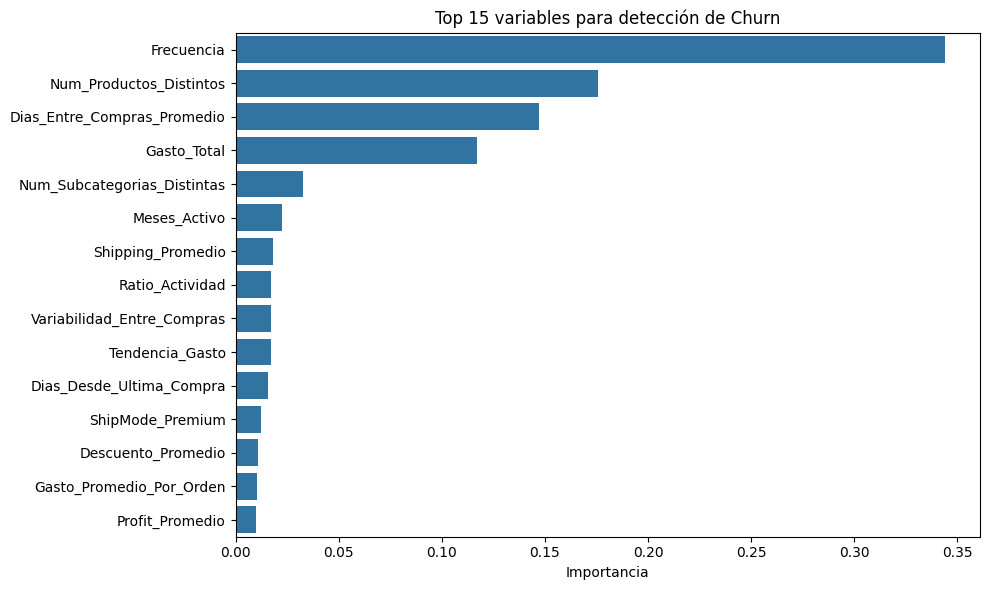

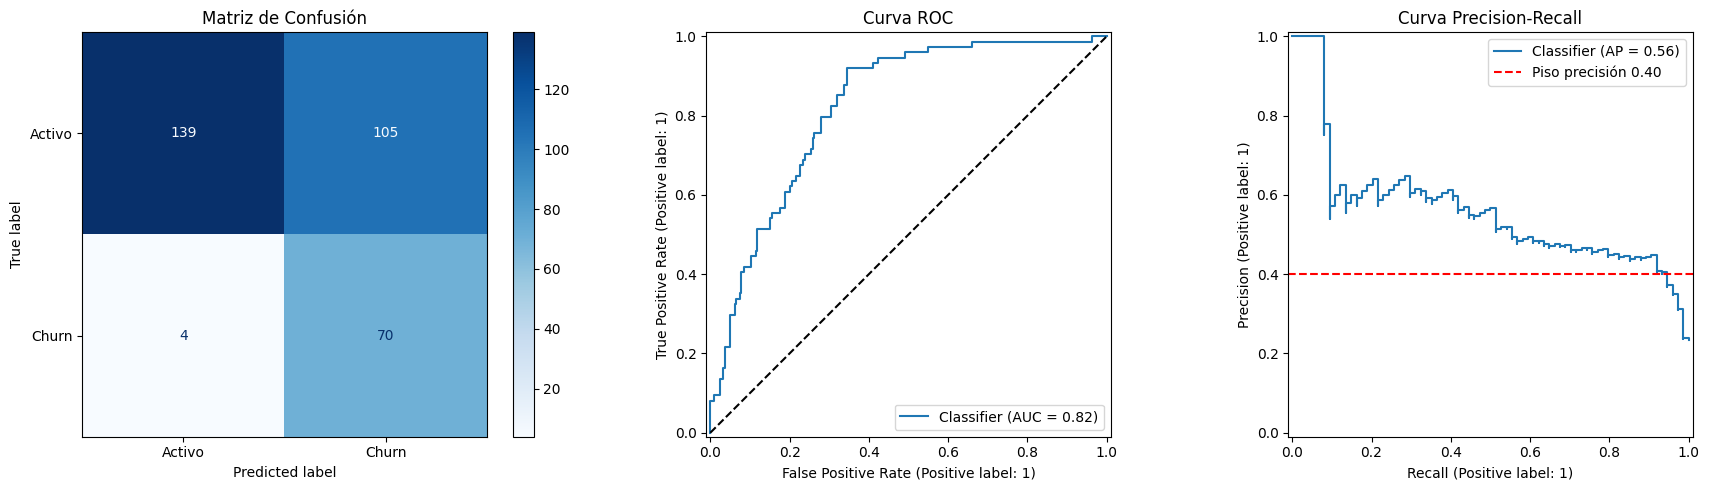

In [40]:
#Gráfica de las variables más importantes para la detección de fuga de clientes (Churn) y validar el modelo con matriz de confusión, curva ROC y curva Precision-Recall

# ── 1. VARIABLES MÁS IMPORTANTES ────────────────────────────────
modelo_rf   = buscador.best_estimator_.named_steps['modelo']
prepro      = buscador.best_estimator_.named_steps['preprocesamiento']

# Nombres de columnas tras el preprocesamiento
nombres_cat = prepro.named_transformers_['cat'].get_feature_names_out(variables_categoricas)
nombres_all = list(nombres_cat) + variables_numericas

importancias = modelo_rf.feature_importances_
idx = np.argsort(importancias)[::-1][:15]  # top 15

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias[idx], y=np.array(nombres_all)[idx])
plt.title('Top 15 variables para detección de Churn')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# ── 2. VALIDACIÓN DEL MODELO ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_c, pred_final,
    display_labels=['Activo', 'Churn'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test_c, probabilidades, ax=axes[1]
)
axes[1].set_title('Curva ROC')
axes[1].plot([0,1],[0,1], 'k--')

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_test_c, probabilidades, ax=axes[2]
)
axes[2].set_title('Curva Precision-Recall')
axes[2].axhline(y=0.40, color='r', linestyle='--', label='Piso precisión 0.40')
axes[2].legend()

plt.tight_layout()
plt.show()


Observando las variables vemos como primera el Número de productos distintos.
Tiene mucho sentido si lo pensás desde el comportamiento del cliente:

Un cliente que compra muchos productos distintos está más "enganchado" con la tienda. Exploró el catálogo, probó diferentes categorías, confía en la marca. Ese cliente tiene más razones para volver.

Un cliente que siempre compra lo mismo (1-2 productos distintos) tiene una relación frágil — compra por necesidad puntual o precio, no por lealtad. Si encuentra ese producto más barato en otro lado, se va.

En la práctica esto significa:

Si el Cliente compra Tables y solo hay 2 tipos de tables el riesgo es Alto mientras que si compra Tables, Chairs, Binders, etc y hay mucha variedad de productos el riesgo pasa a ser Bajo.

Es una señal de profundidad de relación con la tienda — más diversidad = más dependencia = menos churn.

Implicancia de negocio concreta: los clientes con pocos productos distintos son el segmento prioritario para campañas de cross-selling. Si lográs que prueben otra categoría, reducís su riesgo de fuga. Esto es accionable directamente desde el modelo.


En síntesis, este modelo permite detectar los clientes en peligro de fuga y enviarles mensajes necesarios y adecuados para su retención en nuestro mercado. Es correcto señalar que también detecta como clientes en peligro a muchos que están activos por lo que es prudente que los mensajes estén ambientados hacia ambos. Hay que considerar que este modelo fué entrenado con pocos datos debido a que el porcentaje de churn en el data set era bajo y se tuvo que readecuar el tiempo para mejorar los parámetros. Sería conveniente seguir aumentando el dataset respecto a estas variables para mejorar el balance e incrementar la distinción entre churns y activos.

In [ ]:
#Importamos joblib para guardar los modelos entrenados de churn y rentabilidad en archivos .pkl para su uso futuro


# Guardar modelo de churn (Random Forest, ROC-AUC 0.82)
joblib.dump(buscador.best_estimator_, 'modelo_churn.pkl')
print("Modelo churn guardado: modelo_churn.pkl")

# Guardar modelo de rentabilidad (el mejor que entrenaste — ajustá el nombre de variable)
joblib.dump(mejor_modelo, 'modelo_rentabilidad.pkl')
print("Modelo rentabilidad guardado: modelo_rentabilidad.pkl")


Modelo churn guardado: modelo_churn.pkl
Modelo rentabilidad guardado: modelo_rentabilidad.pkl


<a id="s11"></a>

## 11. Conclusiones


Conclusión: Modelo de Predicción de Rentabilidad

El modelo de Random Forest entrenado con validación cruzada y optimización de hiperparámetros logró una exactitud del 91.6%, superando consistentemente al árbol de decisión base. La variable más determinante fue el descuento aplicado, lo que refuerza directamente la hipótesis planteada al inicio del análisis: la política de descuentos agresivos es el principal factor de pérdida en Global Superstore.

Este modelo aporta valor operativo concreto — permite evaluar una transacción antes de concretarse y anticipar si generará pérdida, habilitando intervenciones como ajuste de descuento, cambio de modalidad de envío o revisión de categoría de producto. La limitación principal es que el recall para la clase de pérdida (0.80) implica que un 20% de las operaciones no rentables aún escapan al modelo, lo que deja margen de mejora si se incorporan variables adicionales como costos logísticos detallados por proveedor.

Conclusión: Modelo de Detección de Fuga de Clientes (Churn)

El modelo de detección de churn alcanzó un ROC-AUC de 0.82, resultado que fue posible gracias a dos decisiones metodológicas clave: la construcción de un conjunto enriquecido de features comportamentales por cliente (que va más allá del RFM tradicional e incorpora tendencia de gasto, ratio de actividad y diversidad de productos) y la búsqueda sistemática de la ventana temporal óptima de 105 días, que balanceó la tasa de churn y la performance del modelo.

La variable de mayor poder predictivo resultó ser el número de productos distintos adquiridos, interpretada como una señal de profundidad de relación con la marca. Esto habilita una acción de negocio directa: priorizar campañas de cross-selling en clientes con baja diversidad de compra antes de que abandonen el mercado.

El modelo detecta el 95% de los churners reales con una precisión del 40%, lo que implica que por cada cliente en riesgo real detectado se generan aproximadamente 1.5 falsas alarmas. Este trade-off es aceptable en el contexto de retención, donde el costo de contactar un cliente activo es significativamente menor que el costo de perder uno. Como línea de mejora, ampliar el dataset histórico permitiría reducir ese margen de error y mejorar la distinción entre ambas clases.

Síntesis del Proyecto

Ambos modelos responden al problema original planteado para Global Superstore: identificar focos de ineficiencia financiera y oportunidades de retención. El modelo de rentabilidad actúa a nivel transacción — previniendo pérdidas antes de que ocurran. El modelo de churn actúa a nivel cliente — identificando relaciones en riesgo antes de que se rompan. Juntos conforman una capa predictiva que complementa el análisis exploratorio y permite pasar del diagnóstico a la acción.